# Prospect League Inning Simulator — Part 1

# Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import random
from collections import defaultdict

PKL = "#fill with pkl data path"
TERMINAL = (0, 0, 0, 3)

df = pd.read_pickle(PKL).copy()
df["seq"] = df["play_seq"].astype(int)
df = df.sort_values(["game_id", "inning", "half", "seq"]).reset_index(drop=True)
df = df[df["start_outs"] <= 2].reset_index(drop=True) 

def _state(base_state, outs):
    b = str(base_state)
    return (int(b[0]), int(b[1]), int(b[2]), int(outs))

rows = []
for _, grp in df.groupby(["game_id", "inning", "half"], sort=False):
    recs = grp[["base_state", "start_outs", "rei"]].values.tolist()
    for j, (bs, outs, rei) in enumerate(recs):
        before = _state(bs, outs)
        if j + 1 < len(recs):
            nb, no, nrei = recs[j + 1]
            after, runs = _state(nb, no), rei - nrei
        else:
            after, runs = TERMINAL, rei          # last PA: its runs equal its rei
        rows.append({"before": before, "after": after, "runs": max(0, runs)}) # gets rid of 53 instances of 3+ out events

print(f"{len(rows)} transitions from {df['game_id'].nunique()} games")

153970 transitions from 1983 games


## Transition table

Turn the raw transitions into probabilities — for each state, 
what can happen next and how often.

In [4]:
def build_table(rows):
    counts = defaultdict(lambda: defaultdict(int))
    for e in rows:
        counts[e["before"]][(e["after"], e["runs"])] += 1
    table = {}
    for before, outcomes in counts.items():
        total = sum(outcomes.values())
        results = list(outcomes.keys())
        weights = [c / total for c in outcomes.values()]
        table[before] = (results, weights)
    return table

table = build_table(rows)
print(f"states populated: {len(table)} / 24\n")

# what can happen from bases-empty, nobody out (most likely outcomes first):
print("from (0,0,0,0):")
for (nxt, r), p in sorted(zip(*table[(0, 0, 0, 0)]), key=lambda x: -x[1])[:8]:
    print(f"  -> {nxt}  +{r} run(s)   p = {p:.3f}")

states populated: 24 / 24

from (0,0,0,0):
  -> (0, 0, 0, 1)  +0 run(s)   p = 0.607
  -> (1, 0, 0, 0)  +0 run(s)   p = 0.260
  -> (0, 1, 0, 0)  +0 run(s)   p = 0.097
  -> (0, 0, 1, 0)  +0 run(s)   p = 0.019
  -> (0, 0, 0, 0)  +1 run(s)   p = 0.016
  -> (0, 0, 0, 0)  +0 run(s)   p = 0.000


`sim_inning` walks the table from bases-empty / nobody-out, drawing a random outcome
each step until three outs. `sim_game_runs` sums nine innings. Run many games and you
get a distribution.

ten sample innings: [2, 0, 1, 0, 0, 3, 3, 1, 0, 0]
mean runs per game: 6.83


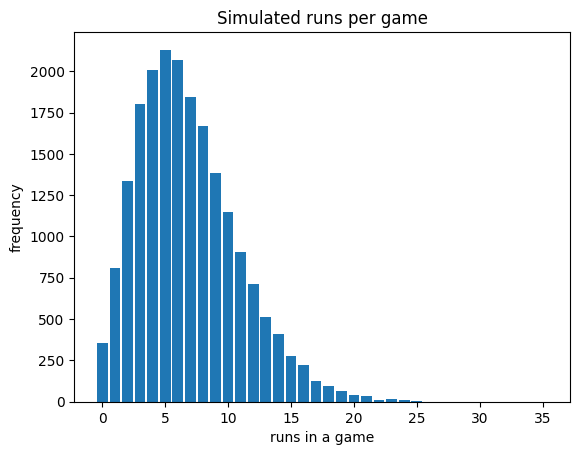

In [ ]:
def sim_inning(table):
    state, runs = (0, 0, 0, 0), 0
    while state[3] < 3:
        entry = table.get(state)
        if entry is None:
            break
        (state, scored), = random.choices(entry[0], weights=entry[1], k=1)
        runs += scored
    return runs

def sim_game_runs(table, innings=9):
    return sum(sim_inning(table) for _ in range(innings))

print("ten sample innings:", [sim_inning(table) for _ in range(10)])

sims = [sim_game_runs(table) for _ in range(20000)]
print("mean runs per game:", round(sum(sims) / len(sims), 2))

plt.hist(sims, bins=range(0, max(sims) + 2), align="left", rwidth=0.85)
plt.xlabel("runs in a game"); plt.ylabel("frequency")
plt.title("Simulated runs per game")
plt.show()

## Comparison to RE Matrix

`re_from_sim` averages the runs from a chosen state to the end of the inning. So the
simulator's value for each state should match the matrix cell for that state. When they
line up, the sim is working correctly

In [6]:
def re_from_sim(table, start_state, n=50000):
    total = 0
    for _ in range(n):
        state, runs = start_state, 0
        while state[3] < 3:
            entry = table.get(state)
            if entry is None:
                break
            (state, scored), = random.choices(entry[0], weights=entry[1], k=1)
            runs += scored
        total += runs
    return total / n

for state in [(0,0,0,0), (1,0,0,0), (0,1,0,0), (0,0,1,0), (1,1,1,0), (0,0,0,1), (0,0,0,2)]:
    print(f"{state}:  sim RE = {re_from_sim(table, state):.3f}")

(0, 0, 0, 0):  sim RE = 0.754
(1, 0, 0, 0):  sim RE = 1.239
(0, 1, 0, 0):  sim RE = 1.460
(0, 0, 1, 0):  sim RE = 1.686
(1, 1, 1, 0):  sim RE = 2.840
(0, 0, 0, 1):  sim RE = 0.381
(0, 0, 0, 2):  sim RE = 0.135
